# 1000 Genomes VCF 데이터 EDA

## 이 노트북에서 하는 것

1000 Genomes Project의 VCF(Variant Call Format) 데이터를 탐색합니다.

**데이터 요약:**
- 2,504명의 전 세계 사람들
- 22개 상염색체 (chr1 ~ chr22)
- 각 위치마다 "변이가 있다/없다" 기록

**VCF 데이터 읽는 법:**
```
chr1:10177  REF=A  ALT=AC  GT=(1, 0)
│           │      │       └─ 이 사람: 한쪽은 변이(1), 한쪽은 기준(0)
│           │      └─ 변이가 있으면 이 서열
│           └─ 기준 유전체는 이 서열
└─ 1번 염색체의 10177번째 위치
```

사람은 부모에게 각각 DNA 가닥 1개씩 받으므로, **한 사람 = 2개 값**:
- `(0,0)` = 양쪽 다 기준 → 변이 없음
- `(1,0)` or `(0,1)` = 한쪽만 변이 (heterozygous, 이형접합)
- `(1,1)` = 양쪽 다 변이 (homozygous, 동형접합)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import seaborn as sns
import pysam
from collections import Counter

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 경로 설정
VCF_DIR = os.path.expanduser('~/GeneDiffusion')
VCF_PATTERN = 'ALL.chr{chrom}.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz'
DATA_DIR = os.path.expanduser('~/gene-synthesis-project/data')

print('준비 완료!')

준비 완료!


---
## Step 1: 데이터 구조 살펴보기

VCF 파일 하나를 열어서 어떤 정보가 들어있는지 직접 확인합니다.

> **핵심 질문: "이 데이터에 뭐가 들어있지?"**

In [2]:
# chr22를 사용 (가장 작아서 빠름)
vcf_path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=22))
vcf = pysam.VariantFile(vcf_path)

# 기본 정보
samples = list(vcf.header.samples)
print(f'샘플(사람) 수: {len(samples):,}명')
print(f'앞 10명: {samples[:10]}')
print(f'\n각 샘플 ID는 1000 Genomes 고유 코드입니다.')

샘플(사람) 수: 2,504명
앞 10명: ['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101', 'HG00102', 'HG00103', 'HG00105', 'HG00106', 'HG00107']

각 샘플 ID는 1000 Genomes 고유 코드입니다.


In [3]:
# 첫 10개 variant를 표로 정리
rows = []
vcf2 = pysam.VariantFile(vcf_path)
for i, rec in enumerate(vcf2):
    if i >= 10:
        break
    # 앞 3명의 genotype
    gts = [rec.samples[s]['GT'] for s in samples[:3]]
    rows.append({
        '위치': f'chr22:{rec.pos:,}',
        '기준(REF)': rec.ref,
        '변이(ALT)': ','.join(rec.alts) if rec.alts else '.',
        '변이종류': 'SNP' if len(rec.ref)==1 and rec.alts and len(rec.alts[0])==1 else 'INDEL',
        f'{samples[0]}': f'{gts[0][0]}|{gts[0][1]}',
        f'{samples[1]}': f'{gts[1][0]}|{gts[1][1]}',
        f'{samples[2]}': f'{gts[2][0]}|{gts[2][1]}',
    })
vcf2.close()

df_peek = pd.DataFrame(rows)
print('=== chr22 첫 10개 변이 위치 ===')
print('(마지막 3열은 각 사람의 genotype: 0=기준, 1=변이)')
print()
df_peek

=== chr22 첫 10개 변이 위치 ===
(마지막 3열은 각 사람의 genotype: 0=기준, 1=변이)



,위치,기준(REF),변이(ALT),변이종류,HG00096,HG00097,HG00099
0,"chr22:16,050,075",A,G,SNP,0|0,0|0,0|0
1,"chr22:16,050,115",G,A,SNP,0|0,0|0,0|0
2,"chr22:16,050,213",C,T,SNP,0|0,0|0,0|0
3,"chr22:16,050,319",C,T,SNP,0|0,0|0,0|0
4,"chr22:16,050,527",C,A,SNP,0|0,0|0,0|0
5,"chr22:16,050,568",C,A,SNP,0|0,0|0,0|0
6,"chr22:16,050,607",G,A,SNP,0|0,0|0,0|0
7,"chr22:16,050,627",G,T,SNP,0|0,0|0,0|0
8,"chr22:16,050,646",G,T,SNP,0|0,0|0,0|0
9,"chr22:16,050,654",A,"<CN0>,<CN2>,<CN3>,<CN4>",INDEL,3|0,0|0,0|0


In [4]:
df_peek[df_peek["변이(ALT)"]=="<CN0>,<CN2>,<CN3>,<CN4>"]

,위치,기준(REF),변이(ALT),변이종류,HG00096,HG00097,HG00099
9,"chr22:16,050,654",A,"<CN0>,<CN2>,<CN3>,<CN4>",INDEL,3|0,0|0,0|0


---
## Step 2: 염색체별 변이 수 비교

22개 염색체마다 변이가 몇 개인지 셉니다.

> **핵심 질문: "어느 염색체에 변이가 많을까?"**
>
> 예상: 긴 염색체(chr1)가 가장 많고, 짧은 염색체(chr21, 22)가 가장 적을 것

/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2493169799.py:36: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) Deja

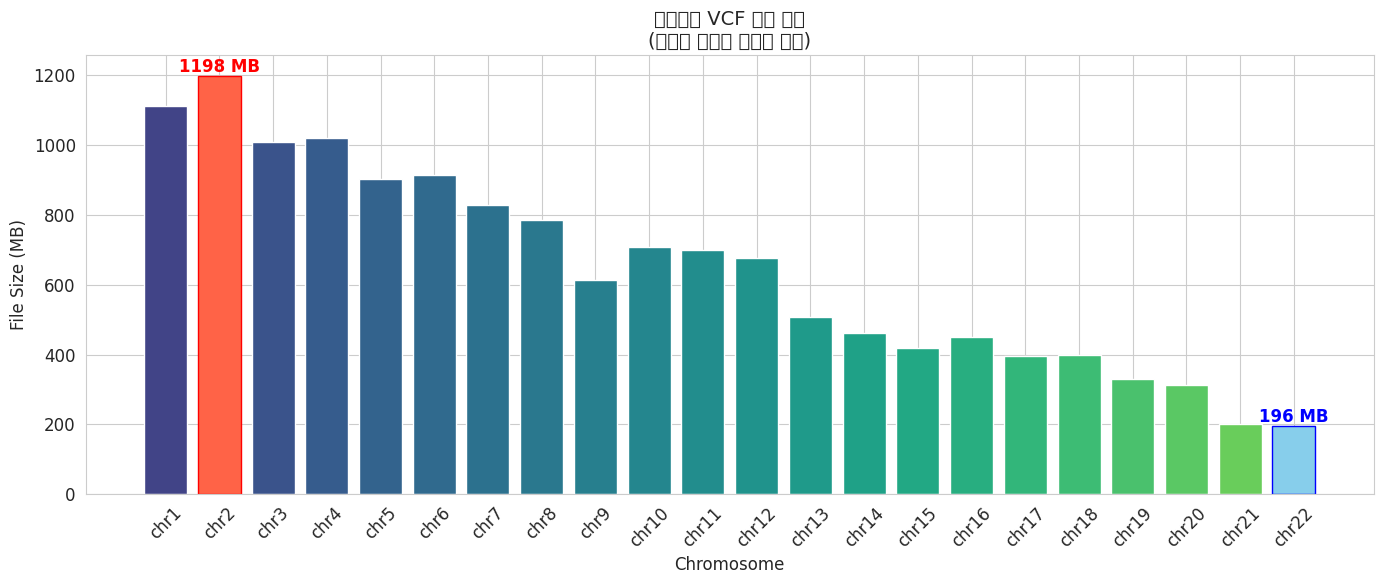

총 크기: 13.8 GB
가장 큰 염색체: chr2 (1198 MB)
가장 작은 염색체: chr22 (196 MB)


In [5]:
# 각 염색체의 variant 수 세기 (파일 크기로 빠르게 추정 + 실제 카운트)
# 전부 세면 오래 걸리므로, 파일 크기 기반 추정도 함께 보여줍니다

chrom_stats = []
for c in range(1, 23):
    path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=c))
    size_mb = os.path.getsize(path) / (1024**2)
    chrom_stats.append({'chrom': c, 'label': f'chr{c}', 'size_mb': size_mb})

df_chrom = pd.DataFrame(chrom_stats)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 22))
bars = ax.bar(df_chrom['label'], df_chrom['size_mb'], color=colors, edgecolor='white')

ax.set_xlabel('Chromosome')
ax.set_ylabel('File Size (MB)')
ax.set_title('염색체별 VCF 파일 크기\n(파일이 클수록 변이가 많음)', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# 가장 큰 것, 작은 것 표시
max_idx = df_chrom['size_mb'].idxmax()
min_idx = df_chrom['size_mb'].idxmin()
bars[max_idx].set_color('tomato')
bars[max_idx].set_edgecolor('red')
bars[min_idx].set_color('skyblue')
bars[min_idx].set_edgecolor('blue')

ax.annotate(f'{df_chrom.loc[max_idx, "size_mb"]:.0f} MB',
            xy=(max_idx, df_chrom.loc[max_idx, 'size_mb']),
            ha='center', va='bottom', fontweight='bold', color='red')
ax.annotate(f'{df_chrom.loc[min_idx, "size_mb"]:.0f} MB',
            xy=(min_idx, df_chrom.loc[min_idx, 'size_mb']),
            ha='center', va='bottom', fontweight='bold', color='blue')

plt.tight_layout()
plt.show()

print(f'총 크기: {df_chrom["size_mb"].sum()/1024:.1f} GB')
print(f'가장 큰 염색체: chr{df_chrom.loc[max_idx, "chrom"]} ({df_chrom.loc[max_idx, "size_mb"]:.0f} MB)')
print(f'가장 작은 염색체: chr{df_chrom.loc[min_idx, "chrom"]} ({df_chrom.loc[min_idx, "size_mb"]:.0f} MB)')

---
## Step 3: 변이 빈도 분석 (MAF)

**MAF (Minor Allele Frequency)** = 변이가 전체 인구에서 얼마나 흔한지

```
MAF = 0.01  →  100명 중 1명만 가진 희귀 변이
MAF = 0.10  →  10명 중 1명이 가짐
MAF = 0.50  →  절반이 가짐 (가장 흔함)
```

> **핵심 질문: "변이 대부분이 희귀한가, 흔한가?"**
>
> 진화적으로 새로운 변이는 아직 퍼지지 않았으므로, **대부분 희귀 변이**일 것

전체 데이터는 너무 크므로, **chr22 (가장 작음)** 에서 샘플링합니다.

In [6]:
# chr22에서 MAF 계산 (병렬 처리)
from multiprocessing import Pool, cpu_count

def _calc_maf_chunk(args):
    """VCF 파일의 특정 구간에서 MAF/variant_type 계산"""
    vcf_path, start_idx, chunk_size = args
    import pysam
    vcf = pysam.VariantFile(vcf_path)

    mafs_local = []
    types_local = []

    for i, rec in enumerate(vcf):
        if i < start_idx:
            continue
        if i >= start_idx + chunk_size:
            break
        if not rec.alts:
            continue

        alt_count = 0
        total_alleles = 0
        for s in rec.samples.values():
            gt = s['GT']
            if gt[0] is not None:
                alt_count += gt[0] + gt[1]
                total_alleles += 2

        if total_alleles == 0:
            continue

        af = alt_count / total_alleles
        maf = min(af, 1 - af)
        mafs_local.append(maf)

        if len(rec.ref) == 1 and len(rec.alts[0]) == 1:
            types_local.append('SNP')
        else:
            types_local.append('INDEL')

    vcf.close()
    return mafs_local, types_local

# 총 variant 수 먼저 세기 (빠르게)
vcf_path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=22))
vcf = pysam.VariantFile(vcf_path)
n_total = sum(1 for _ in vcf)
vcf.close()
print(f'chr22 총 레코드: {n_total:,}개')

# 청크 분할 후 병렬 처리
n_workers = max(8, cpu_count())
chunk_size = (n_total + n_workers - 1) // n_workers
tasks = [(vcf_path, i * chunk_size, chunk_size) for i in range(n_workers)]

print(f'병렬 MAF 계산 중 ({n_workers} workers, 청크당 ~{chunk_size:,}개)...')
import time
t0 = time.time()

with Pool(n_workers) as pool:
    results = pool.map(_calc_maf_chunk, tasks)

mafs = []
variant_types = []
for m, t in results:
    mafs.extend(m)
    variant_types.extend(t)

mafs = np.array(mafs)
elapsed = time.time() - t0
print(f'\n완료! chr22 총 {len(mafs):,}개 변이 ({elapsed:.0f}s)')

chr22 총 레코드: 1,103,547개
병렬 MAF 계산 중 (32 workers, 청크당 ~34,486개)...

완료! chr22 총 1,103,547개 변이 (109s)


/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 55124 (\N{HANGUL SYLLABLE HEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/4052827623.py:31: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaV

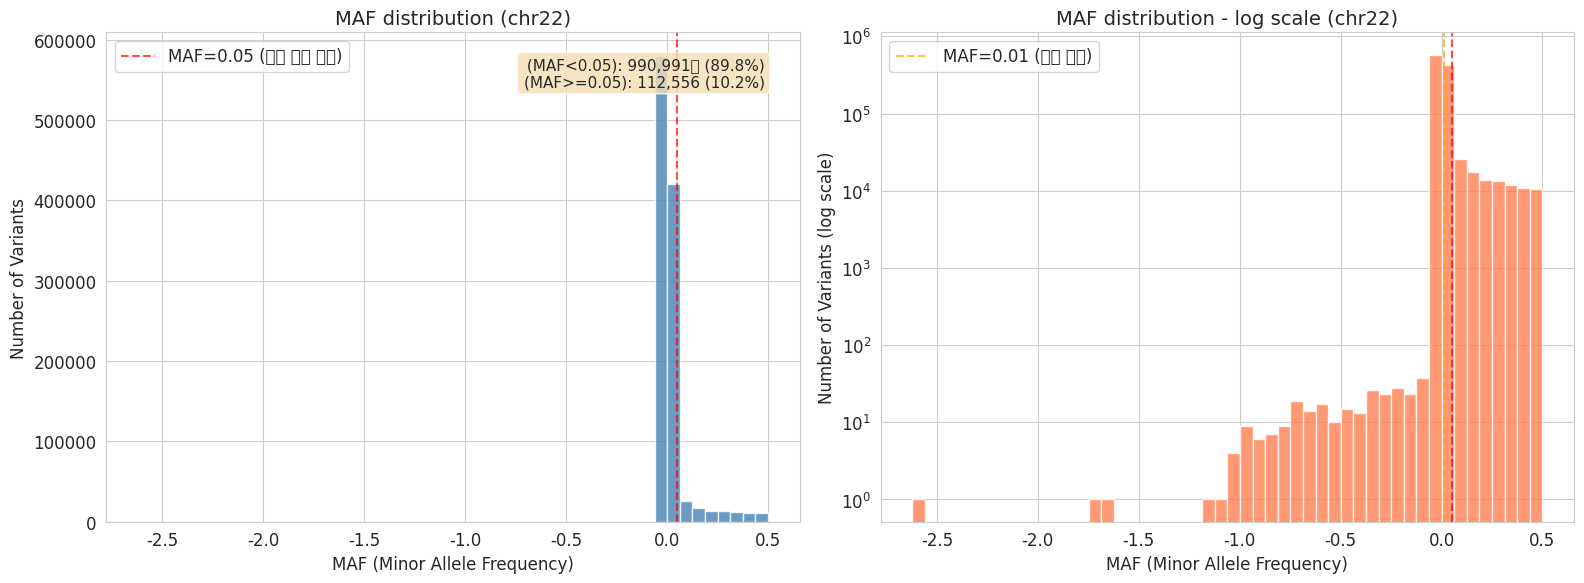


해석:
  - 변이의 대다수(90%)가 MAF < 0.05 → 희귀 변이
  - 진화적으로 새로 생긴 변이는 아직 퍼지지 않았기 때문
  - 합성 데이터 모델은 이 "희귀 변이 쏠림"을 잘 재현해야 함


In [9]:
# MAF 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 전체 MAF 분포
ax = axes[0]
ax.hist(mafs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('MAF (Minor Allele Frequency)')
ax.set_ylabel('Number of Variants')
ax.set_title('MAF distribution (chr22)', fontsize=14)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='MAF=0.05 (흔한 변이 기준)')
ax.legend()

# 비율 텍스트
rare = (mafs < 0.05).sum()
common = (mafs >= 0.05).sum()
ax.text(0.95, 0.95, f' (MAF<0.05): {rare:,}개 ({rare/len(mafs)*100:.1f}%)\n'
        f'(MAF>=0.05): {common:,} ({common/len(mafs)*100:.1f}%)',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=11)

# (2) 로그 스케일로 보기 (희귀 변이 세부)
ax = axes[1]
ax.hist(mafs, bins=50, color='coral', edgecolor='white', alpha=0.8, log=True)
ax.set_xlabel('MAF (Minor Allele Frequency)')
ax.set_ylabel('Number of Variants (log scale)')
ax.set_title('MAF distribution - log scale (chr22)', fontsize=14)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=0.01, color='orange', linestyle='--', alpha=0.7, label='MAF=0.01 (매우 희귀)')
ax.legend()

plt.tight_layout()
plt.show()

print('\n해석:')
print(f'  - 변이의 대다수({rare/len(mafs)*100:.0f}%)가 MAF < 0.05 → 희귀 변이')
print(f'  - 진화적으로 새로 생긴 변이는 아직 퍼지지 않았기 때문')
print(f'  - 합성 데이터 모델은 이 "희귀 변이 쏠림"을 잘 재현해야 함')

---
## Step 4: 변이 종류 (SNP vs INDEL)

- **SNP (Single Nucleotide Polymorphism)**: 1글자 변이 (A→T)
- **INDEL (Insertion/Deletion)**: 글자가 추가되거나 빠짐 (A→AC, AT→A)

> **핵심 질문: "변이의 대부분이 SNP인가, INDEL인가?"**

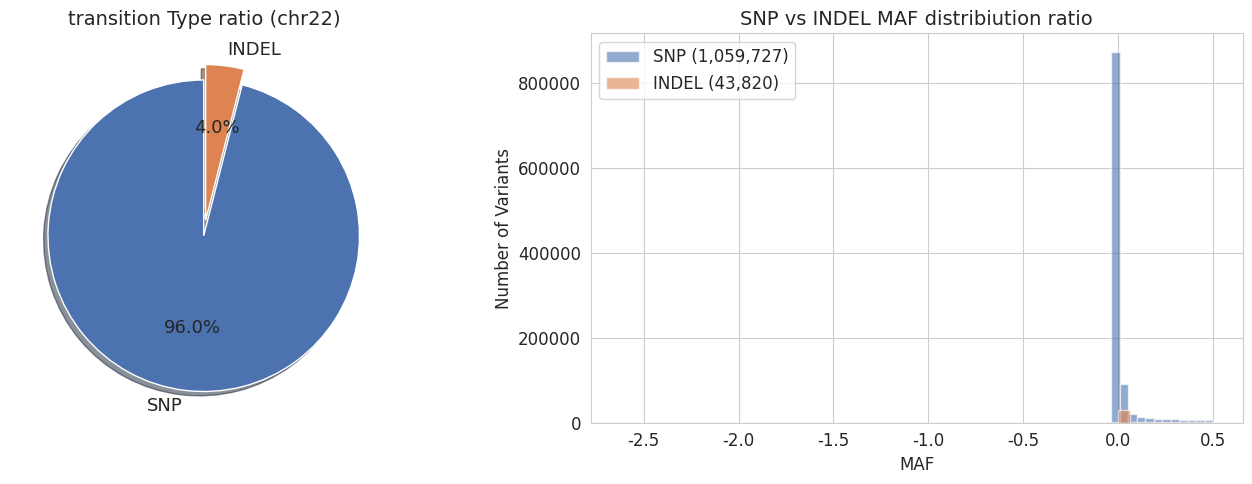

  SNP: 1,059,727개 (96.0%)
  INDEL: 43,820개 (4.0%)


In [10]:
type_counts = Counter(variant_types)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이차트
ax = axes[0]
labels = list(type_counts.keys())
sizes = list(type_counts.values())
colors_pie = ['#4C72B0', '#DD8452']
explode = (0.05, 0.05)
ax.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
       autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 13})
ax.set_title('transition Type ratio (chr22)', fontsize=14)

# SNP vs INDEL 각각의 MAF 분포 비교
ax = axes[1]
snp_mafs = mafs[np.array(variant_types) == 'SNP']
indel_mafs = mafs[np.array(variant_types) == 'INDEL']
ax.hist(snp_mafs, bins=50, alpha=0.6, label=f'SNP ({len(snp_mafs):,})', color='#4C72B0')
ax.hist(indel_mafs, bins=50, alpha=0.6, label=f'INDEL ({len(indel_mafs):,})', color='#DD8452')
ax.set_xlabel('MAF')
ax.set_ylabel('Number of Variants')
ax.set_title('SNP vs INDEL MAF distribiution ratio', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

for vtype, count in type_counts.items():
    print(f'  {vtype}: {count:,}개 ({count/len(mafs)*100:.1f}%)')

---
## Step 5: Genotype 패턴 분석

각 변이 위치에서 사람들의 genotype 분포를 봅니다.

```
0/0 (HomRef)  = 변이 없음      → 대다수
0/1 (Het)     = 한쪽만 변이    → 중간
1/1 (HomAlt)  = 양쪽 다 변이   → 소수
```

> **핵심 질문: "평균적으로 한 위치에서 사람들의 genotype이 어떻게 분포하나?"**

/tmp/ipykernel_4001370/4248579100.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_gt[col] for col in df_gt.columns],
/tmp/ipykernel_4001370/4248579100.py:62: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4001370/4248579100.py:62: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4001370/4248579100.py:62: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4001370/4248579100.py:62: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4001370/4248579100.py:62: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

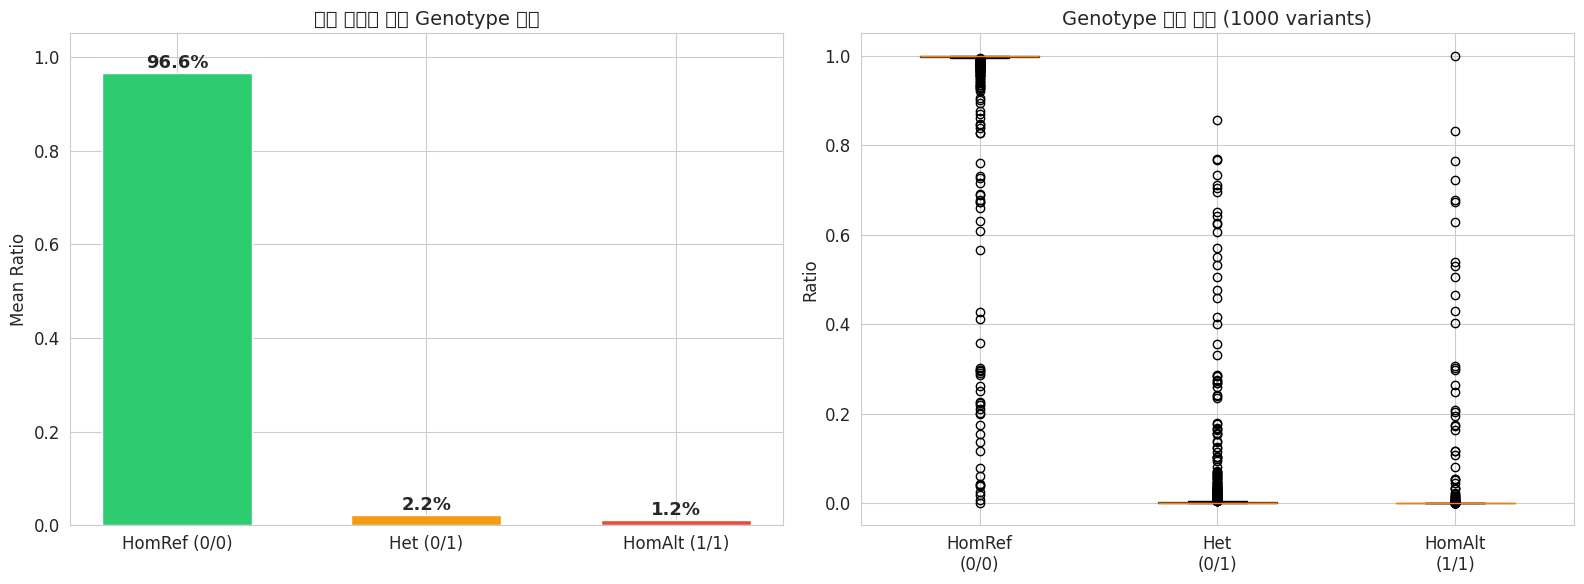

해석:
  - 대부분의 위치에서 거의 모든 사람이 HomRef(변이 없음)
  - 이건 대부분의 변이가 희귀하기 때문 (MAF 분포와 일치)
  - Het가 HomAlt보다 많은 것은 Hardy-Weinberg 법칙과 일치


In [10]:
# chr22에서 1000개 변이 샘플링하여 genotype 비율 분석
vcf_path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=22))
vcf = pysam.VariantFile(vcf_path)

gt_ratios = []  # 각 변이에서의 HomRef/Het/HomAlt 비율
sample_step = 5  # 5개 중 1개만 샘플링 (속도)

for i, rec in enumerate(vcf):
    if i % sample_step != 0:
        continue
    if i // sample_step >= 1000:
        break

    hom_ref = het = hom_alt = missing = 0
    for s in rec.samples.values():
        gt = s['GT']
        if gt[0] is None:
            missing += 1
        elif gt[0] == 0 and gt[1] == 0:
            hom_ref += 1
        elif gt[0] == gt[1]:
            hom_alt += 1
        else:
            het += 1

    total = hom_ref + het + hom_alt
    if total > 0:
        gt_ratios.append({
            'HomRef (0/0)': hom_ref / total,
            'Het (0/1)': het / total,
            'HomAlt (1/1)': hom_alt / total,
        })

vcf.close()
df_gt = pd.DataFrame(gt_ratios)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 평균 비율 막대 그래프
ax = axes[0]
means = df_gt.mean()
colors_gt = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(means.index, means.values, color=colors_gt, edgecolor='white', width=0.6)
ax.set_ylabel('Mean Ratio')
ax.set_title('변이 위치별 평균 Genotype 비율', fontsize=14)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1.05)

# (2) 분포 boxplot
ax = axes[1]
bp = ax.boxplot([df_gt[col] for col in df_gt.columns],
                labels=['HomRef\n(0/0)', 'Het\n(0/1)', 'HomAlt\n(1/1)'],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors_gt):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Ratio')
ax.set_title('Genotype 비율 분포 (1000 variants)', fontsize=14)

plt.tight_layout()
plt.show()

print('해석:')
print(f'  - 대부분의 위치에서 거의 모든 사람이 HomRef(변이 없음)')
print(f'  - 이건 대부분의 변이가 희귀하기 때문 (MAF 분포와 일치)')
print(f'  - Het가 HomAlt보다 많은 것은 Hardy-Weinberg 법칙과 일치')

---
## Step 6: Population Structure (PCA)

2,504명을 유전적 유사도 기준으로 2D에 점으로 찍으면, **같은 대륙 출신끼리 모입니다.**

이것이 PCA (Principal Component Analysis) 입니다.

5개 대륙 그룹 (Super Population):
- **AFR**: 아프리카
- **AMR**: 아메리카 (혼합)
- **EAS**: 동아시아
- **EUR**: 유럽
- **SAS**: 남아시아

> **핵심 질문: "유전자만으로 사람들의 출신을 구분할 수 있나?"**

⚠️ chr22의 흔한 변이(MAF>0.05)만 사용합니다 (속도 + PCA는 흔한 변이가 효과적)

In [14]:
# Population 메타데이터 로드
panel_path = os.path.join(DATA_DIR, 'integrated_call_samples_v3.20130502.ALL.panel')
df_pop = pd.read_csv(panel_path, sep='\t')
df_pop = df_pop[['sample', 'pop', 'super_pop', 'gender']].dropna(subset=['sample'])

print('=== Population 정보 ===')
print(f'총 {len(df_pop)}명')
print(f'\n대륙별 인원수:')
print(df_pop['super_pop'].value_counts().to_string())
print(f'\n세부 population 수: {df_pop["pop"].nunique()}개')

=== Population 정보 ===
총 2504명

대륙별 인원수:
super_pop
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347

세부 population 수: 26개


In [12]:
# chr22에서 흔한 SNP만 추출하여 genotype 행렬 만들기
from sklearn.decomposition import PCA

vcf_path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=22))
vcf = pysam.VariantFile(vcf_path)
samples = list(vcf.header.samples)
n_samples = len(samples)

genotype_rows = []
n_variants = 0
max_variants = 5000  # PCA에 충분한 수

print('흔한 SNP 추출 중 (MAF >= 0.05, biallelic SNP만)...') # biallelic은 (0,1), (1,0) 과 같이 한개만 변이되는 경우를 말함. 양쪽변이는 제외 
for rec in vcf:
    if n_variants >= max_variants:
        break

    # biallelic SNP만
    if not rec.alts or len(rec.alts) != 1:
        continue
    if len(rec.ref) != 1 or len(rec.alts[0]) != 1:
        continue

    # genotype 추출: 0, 1, 2 (ALT allele 수)
    gts = []
    for s in rec.samples.values():
        gt = s['GT']
        if gt[0] is None:
            gts.append(np.nan)
        else:
            gts.append(gt[0] + gt[1])  # 0, 1, or 2

    gts = np.array(gts, dtype=float)

    # MAF 필터
    valid = ~np.isnan(gts)
    if valid.sum() == 0:
        continue
    af = np.nansum(gts) / (2.0 * valid.sum())
    maf = min(af, 1 - af)
    if maf < 0.05:
        continue

    # missing 평균으로 대체
    gts[~valid] = np.nanmean(gts)
    genotype_rows.append(gts)
    n_variants += 1

    if n_variants % 1000 == 0:
        print(f'  {n_variants:,}개 추출...')

vcf.close()

# (n_variants, n_samples) → 전치하여 (n_samples, n_variants)
geno_matrix = np.array(genotype_rows).T  # (2504, 5000)
print(f'\nGenotype 행렬: {geno_matrix.shape[0]}명 x {geno_matrix.shape[1]} SNPs')

흔한 SNP 추출 중 (MAF >= 0.05, biallelic SNP만)...
  1,000개 추출...
  2,000개 추출...
  3,000개 추출...
  4,000개 추출...
  5,000개 추출...

Genotype 행렬: 2504명 x 5000 SNPs


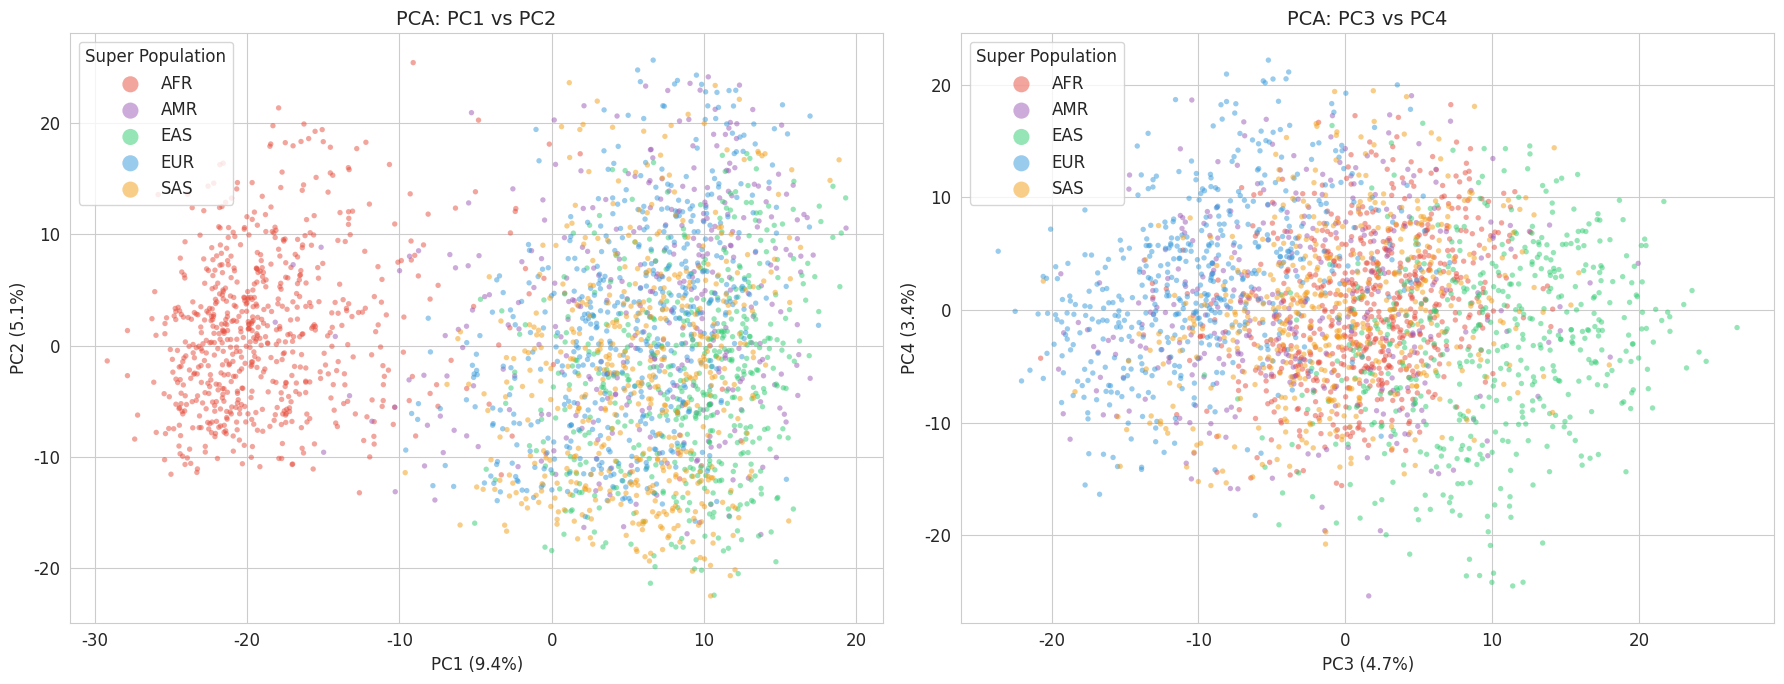

해석:
  - PC1: 아프리카(AFR) vs 나머지를 분리 → 인류의 아프리카 기원 반영
  - PC2: 유럽(EUR)/남아시아(SAS) vs 동아시아(EAS) 분리
  - 같은 대륙 출신이 모여있음 → 유전적 거리 = 지리적 거리
  - 합성 데이터 모델은 이 population structure를 재현해야 함


In [15]:
# PCA 수행
pca = PCA(n_components=4)
pcs = pca.fit_transform(geno_matrix)

# 결과를 DataFrame으로
df_pca = pd.DataFrame({
    'sample': samples,
    'PC1': pcs[:, 0],
    'PC2': pcs[:, 1],
    'PC3': pcs[:, 2],
    'PC4': pcs[:, 3],
})
df_pca = df_pca.merge(df_pop[['sample', 'pop', 'super_pop']], on='sample', how='left')

# 시각화
superpop_colors = {
    'AFR': '#e74c3c',  # 빨강 - 아프리카
    'AMR': '#9b59b6',  # 보라 - 아메리카
    'EAS': '#2ecc71',  # 초록 - 동아시아
    'EUR': '#3498db',  # 파랑 - 유럽
    'SAS': '#f39c12',  # 주황 - 남아시아
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC1 vs PC2
ax = axes[0]
for spop, color in superpop_colors.items():
    mask = df_pca['super_pop'] == spop
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               c=color, label=spop, alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA: PC1 vs PC2', fontsize=14)
ax.legend(title='Super Population', markerscale=3)

# PC3 vs PC4
ax = axes[1]
for spop, color in superpop_colors.items():
    mask = df_pca['super_pop'] == spop
    ax.scatter(df_pca.loc[mask, 'PC3'], df_pca.loc[mask, 'PC4'],
               c=color, label=spop, alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_ylabel(f'PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)')
ax.set_title('PCA: PC3 vs PC4', fontsize=14)
ax.legend(title='Super Population', markerscale=3)

plt.tight_layout()
plt.show()

print('해석:')
print('  - PC1: 아프리카(AFR) vs 나머지를 분리 → 인류의 아프리카 기원 반영')
print('  - PC2: 유럽(EUR)/남아시아(SAS) vs 동아시아(EAS) 분리')
print('  - 같은 대륙 출신이 모여있음 → 유전적 거리 = 지리적 거리')
print('  - 합성 데이터 모델은 이 population structure를 재현해야 함')

---
## Step 7: 대륙별 MAF 비교

같은 변이라도 대륙마다 빈도가 다릅니다.

> **핵심 질문: "어떤 변이가 특정 대륙에서만 흔한가?"**
>
> 이것이 **population-specific variant**이고, 질병 위험도가 인종마다 다른 이유 중 하나

In [16]:
# 대륙별 샘플 인덱스 미리 계산
sample_to_spop = dict(zip(df_pop['sample'], df_pop['super_pop']))
spop_indices = {}
for spop in ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']:
    spop_indices[spop] = [i for i, s in enumerate(samples) if sample_to_spop.get(s) == spop]
    print(f'{spop}: {len(spop_indices[spop])}명')

# chr22 흔한 변이에서 대륙별 MAF 계산
vcf_path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=22))
vcf = pysam.VariantFile(vcf_path)

pop_mafs = {spop: [] for spop in ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']}
n_done = 0

print('\n대륙별 MAF 계산 중...')
for rec in vcf:
    if not rec.alts or len(rec.alts) != 1:
        continue
    if len(rec.ref) != 1 or len(rec.alts[0]) != 1:
        continue

    all_gts = []
    for s in rec.samples.values():
        gt = s['GT']
        if gt[0] is None:
            all_gts.append(np.nan)
        else:
            all_gts.append(gt[0] + gt[1])
    all_gts = np.array(all_gts, dtype=float)

    # 전체 MAF 필터
    valid = ~np.isnan(all_gts)
    if valid.sum() == 0:
        continue
    af = np.nansum(all_gts) / (2.0 * valid.sum())
    maf_global = min(af, 1 - af)
    if maf_global < 0.05:
        continue

    for spop, indices in spop_indices.items():
        gts_pop = all_gts[indices]
        v = ~np.isnan(gts_pop)
        if v.sum() > 0:
            af_pop = np.nansum(gts_pop) / (2.0 * v.sum())
            pop_mafs[spop].append(min(af_pop, 1 - af_pop))
        else:
            pop_mafs[spop].append(np.nan)

    n_done += 1
    if n_done >= 3000:
        break
    if n_done % 1000 == 0:
        print(f'  {n_done:,}개 처리...')

vcf.close()
print(f'완료: {n_done:,}개 흔한 SNP')

AFR: 661명
AMR: 347명
EAS: 504명
EUR: 503명
SAS: 489명

대륙별 MAF 계산 중...
  1,000개 처리...
  2,000개 처리...
완료: 3,000개 흔한 SNP


/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/1010841976.py:24: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Deja

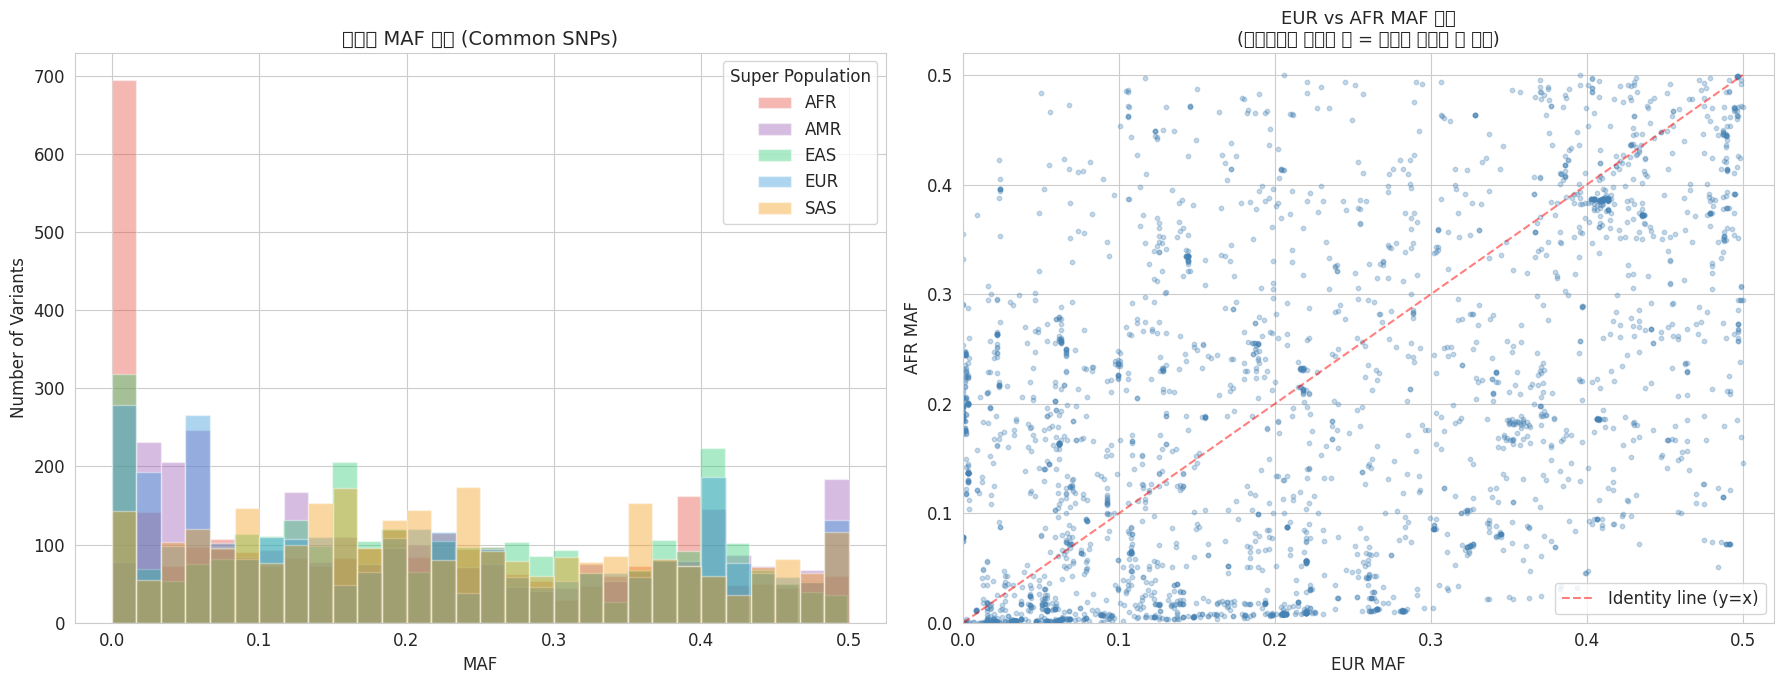


해석:
  - 대부분의 점이 대각선 근처 → 대륙 간 MAF는 비슷한 편
  - 하지만 대각선에서 벗어난 점 610개 = 특정 대륙에서만 흔한 변이
  - 이런 변이가 피부색, 질병 감수성 등의 인종 차이에 관여


In [17]:
# 대륙별 MAF 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (1) 대륙별 MAF 히스토그램
ax = axes[0]
for spop in ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']:
    ax.hist(pop_mafs[spop], bins=30, alpha=0.4, label=spop, color=superpop_colors[spop])
ax.set_xlabel('MAF')
ax.set_ylabel('Number of Variants')
ax.set_title('대륙별 MAF 분포 (Common SNPs)', fontsize=14)
ax.legend(title='Super Population')

# (2) AFR vs EUR 산점도
ax = axes[1]
ax.scatter(pop_mafs['EUR'], pop_mafs['AFR'], alpha=0.3, s=10, c='steelblue')
ax.plot([0, 0.5], [0, 0.5], 'r--', alpha=0.5, label='Identity line (y=x)')
ax.set_xlabel('EUR MAF')
ax.set_ylabel('AFR MAF')
ax.set_title('EUR vs AFR MAF 비교\n(대각선에서 벗어난 점 = 대륙간 차이가 큰 변이)', fontsize=13)
ax.legend()
ax.set_xlim(0, 0.52)
ax.set_ylim(0, 0.52)

plt.tight_layout()
plt.show()

# 대륙간 차이가 큰 변이 비율
afr = np.array(pop_mafs['AFR'])
eur = np.array(pop_mafs['EUR'])
diff = np.abs(afr - eur)
big_diff = (diff > 0.2).sum()
print(f'\n해석:')
print(f'  - 대부분의 점이 대각선 근처 → 대륙 간 MAF는 비슷한 편')
print(f'  - 하지만 대각선에서 벗어난 점 {big_diff}개 = 특정 대륙에서만 흔한 변이')
print(f'  - 이런 변이가 피부색, 질병 감수성 등의 인종 차이에 관여')

---
## Step 8: 개인별 변이 수

> **핵심 질문: "사람마다 변이 수가 다른가? 대륙별로 차이가 있나?"**
>
> 아프리카 출신이 변이가 가장 많을 것 (가장 오래된 집단 → 가장 많은 다양성)

/tmp/ipykernel_4091655/3374384511.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=order, patch_artist=True, widths=0.6)
/tmp/ipykernel_4091655/3374384511.py:44: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/3374384511.py:44: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/3374384511.py:44: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/3374384511.py:44: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/3374384511.py:44: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  

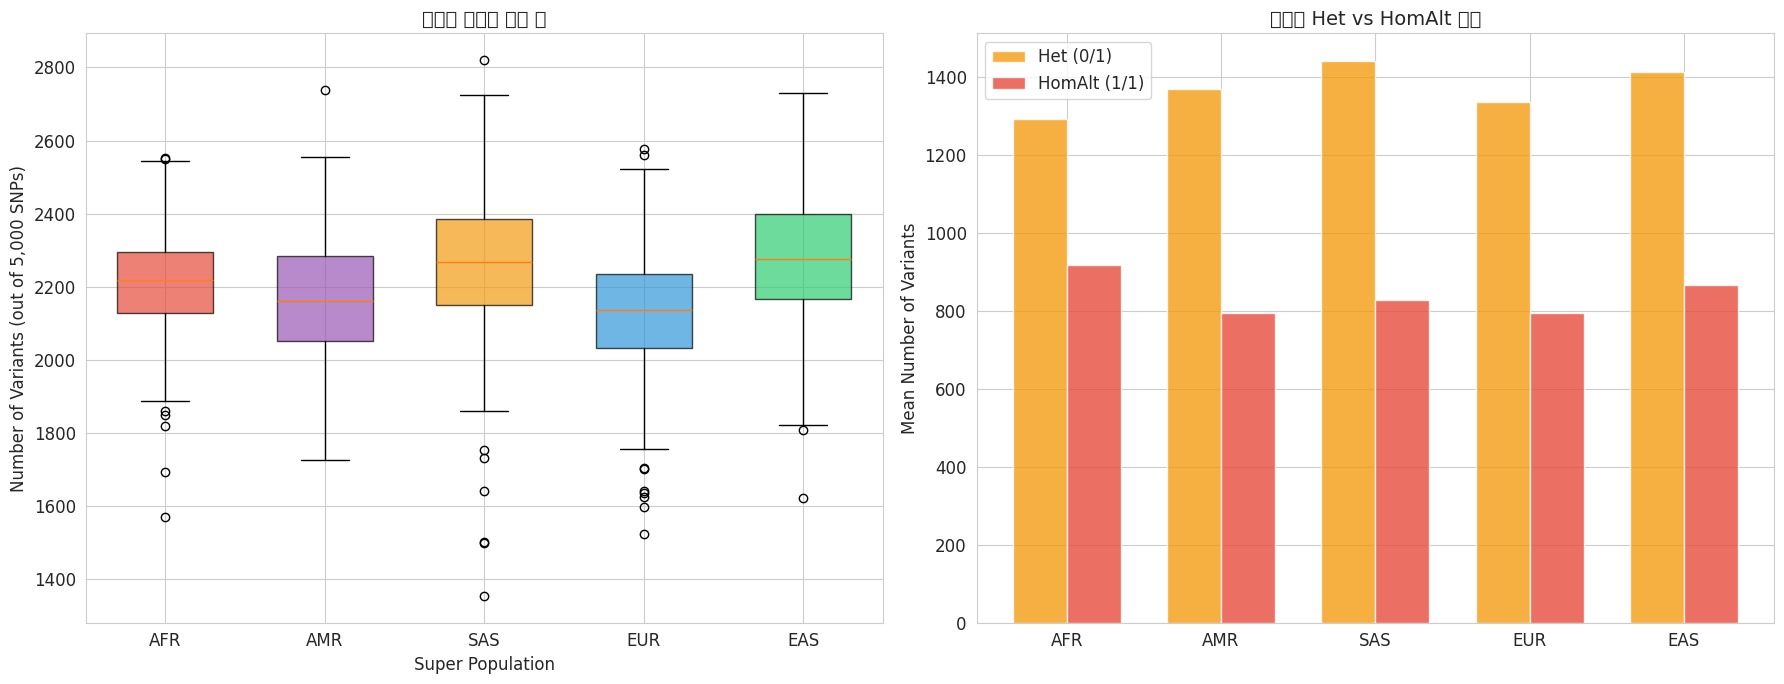

해석:
  - AFR(아프리카)이 변이가 가장 많음 → 인류의 기원지, 유전적 다양성 최대
  - EAS(동아시아)가 가장 적음 → Out-of-Africa 이후 병목 효과
  - Het이 HomAlt보다 많음 → 대부분의 변이는 한쪽에만 있음


In [18]:
# genotype 행렬에서 개인별 변이 수 계산 (이미 추출한 geno_matrix 사용)
# geno_matrix: (2504, 5000) — 0, 1, 2 값

variant_per_person = (geno_matrix > 0).sum(axis=1)  # 변이가 1개라도 있으면 카운트
het_per_person = (geno_matrix == 1).sum(axis=1)      # Het만
homalt_per_person = (geno_matrix == 2).sum(axis=1)   # HomAlt만

df_person = pd.DataFrame({
    'sample': samples,
    'n_variants': variant_per_person,
    'n_het': het_per_person,
    'n_homalt': homalt_per_person,
})
df_person = df_person.merge(df_pop[['sample', 'super_pop']], on='sample', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (1) 대륙별 변이 수 boxplot
ax = axes[0]
order = ['AFR', 'AMR', 'SAS', 'EUR', 'EAS']
bp_data = [df_person.loc[df_person['super_pop'] == sp, 'n_variants'].values for sp in order]
bp = ax.boxplot(bp_data, labels=order, patch_artist=True, widths=0.6)
for patch, sp in zip(bp['boxes'], order):
    patch.set_facecolor(superpop_colors[sp])
    patch.set_alpha(0.7)
ax.set_xlabel('Super Population')
ax.set_ylabel(f'Number of Variants (out of {geno_matrix.shape[1]:,} SNPs)')
ax.set_title('대륙별 개인당 변이 수', fontsize=14)

# (2) Het/HomAlt 비율 비교
ax = axes[1]
het_means = [df_person.loc[df_person['super_pop'] == sp, 'n_het'].mean() for sp in order]
hom_means = [df_person.loc[df_person['super_pop'] == sp, 'n_homalt'].mean() for sp in order]
x = np.arange(len(order))
w = 0.35
ax.bar(x - w/2, het_means, w, label='Het (0/1)', color='#f39c12', alpha=0.8)
ax.bar(x + w/2, hom_means, w, label='HomAlt (1/1)', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel('Mean Number of Variants')
ax.set_title('대륙별 Het vs HomAlt 평균', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print('해석:')
print('  - AFR(아프리카)이 변이가 가장 많음 → 인류의 기원지, 유전적 다양성 최대')
print('  - EAS(동아시아)가 가장 적음 → Out-of-Africa 이후 병목 효과')
print('  - Het이 HomAlt보다 많음 → 대부분의 변이는 한쪽에만 있음')

---
## Step 9: LD (Linkage Disequilibrium)

**LD** = 가까운 위치의 변이가 "함께 유전되는" 정도

```
위치 A에 변이가 있으면, 바로 옆 위치 B에도 변이가 있을 확률이 높다
→ 이 두 변이는 "함께 유전" = LD가 높다 (r² ≈ 1)

멀리 떨어진 위치 C는 독립적으로 유전
→ LD가 낮다 (r² ≈ 0)
```

> **핵심 질문: "변이 간의 거리가 멀어지면 LD가 얼마나 빨리 떨어지나?"**

In [19]:
# chr22에서 흔한 SNP 위치와 genotype 추출 (LD 계산용)
vcf_path = os.path.join(VCF_DIR, VCF_PATTERN.format(chrom=22))
vcf = pysam.VariantFile(vcf_path)
samples_list = list(vcf.header.samples)

positions = []
geno_for_ld = []
max_snps = 2000

print('LD 계산용 SNP 추출 중...')
for rec in vcf:
    if len(geno_for_ld) >= max_snps:
        break
    if not rec.alts or len(rec.alts) != 1:
        continue
    if len(rec.ref) != 1 or len(rec.alts[0]) != 1:
        continue

    gts = []
    for s in rec.samples.values():
        gt = s['GT']
        if gt[0] is None:
            gts.append(np.nan)
        else:
            gts.append(gt[0] + gt[1])
    gts = np.array(gts, dtype=float)

    valid = ~np.isnan(gts)
    if valid.sum() == 0:
        continue
    af = np.nansum(gts) / (2.0 * valid.sum())
    maf = min(af, 1 - af)
    if maf < 0.05:
        continue

    gts[~valid] = np.nanmean(gts)
    geno_for_ld.append(gts)
    positions.append(rec.pos)

vcf.close()

geno_ld = np.array(geno_for_ld)  # (n_snps, n_samples)
positions = np.array(positions)
print(f'{len(positions):,}개 SNP 추출 완료')
print(f'위치 범위: {positions[0]:,} ~ {positions[-1]:,}')

LD 계산용 SNP 추출 중...
2,000개 SNP 추출 완료
위치 범위: 16,051,249 ~ 17,232,922


In [20]:
# LD decay 계산: 거리별 r² 평균
# 모든 쌍 계산은 느리므로, 랜덤 샘플링
n_snps = len(positions)
n_pairs = 50000

rng = np.random.default_rng(42)
idx_i = rng.integers(0, n_snps, size=n_pairs)
idx_j = rng.integers(0, n_snps, size=n_pairs)

# 같은 SNP 쌍 제거
valid_pairs = idx_i != idx_j
idx_i = idx_i[valid_pairs]
idx_j = idx_j[valid_pairs]

distances = np.abs(positions[idx_i] - positions[idx_j])

# r² 계산 (피어슨 상관계수의 제곱)
r_squared = []
for a, b in zip(idx_i, idx_j):
    r = np.corrcoef(geno_ld[a], geno_ld[b])[0, 1]
    r_squared.append(r**2)

r_squared = np.array(r_squared)
print(f'{len(r_squared):,}개 SNP 쌍의 r² 계산 완료')

49,975개 SNP 쌍의 r² 계산 완료


/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 47680 (\N{HANGUL SYLLABLE MEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4091655/2370547388.py:45: UserWarning: Glyph 51460 (\N{HANGUL SYLLABLE JUL}) missing from font(s) DejaVu 

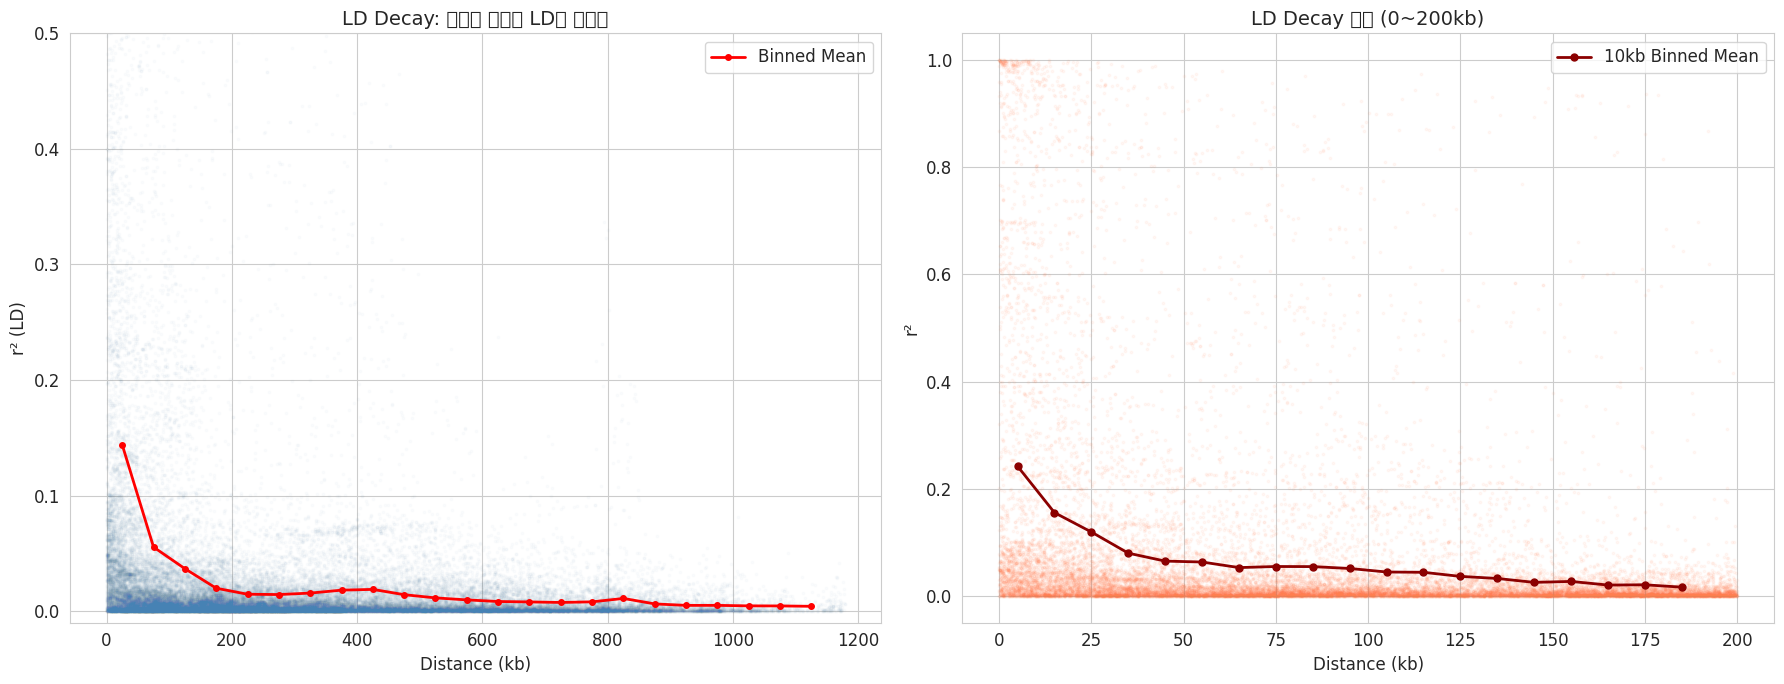

해석:
  - 가까운 SNP끼리는 r²가 높음 (함께 유전됨)
  - ~50kb 이후 급격히 떨어짐 → 재조합(recombination)으로 끊어짐
  - 합성 데이터 모델은 이 LD 패턴을 보존해야 현실적인 데이터를 생성


In [21]:
# LD decay plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (1) 산점도 + binned 평균
ax = axes[0]
ax.scatter(distances / 1000, r_squared, alpha=0.02, s=3, c='steelblue')

# 거리 구간별 평균 r²
dist_kb = distances / 1000
bins = np.arange(0, dist_kb.max(), 50)  # 50kb 구간
bin_centers = []
bin_means = []
for left, right in zip(bins[:-1], bins[1:]):
    mask = (dist_kb >= left) & (dist_kb < right)
    if mask.sum() > 10:
        bin_centers.append((left + right) / 2)
        bin_means.append(r_squared[mask].mean())

ax.plot(bin_centers, bin_means, 'r-o', linewidth=2, markersize=4, label='Binned Mean')
ax.set_xlabel('Distance (kb)')
ax.set_ylabel('r² (LD)')
ax.set_title('LD Decay: 거리가 멀수록 LD가 줄어듦', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(-0.01, 0.5)

# (2) 가까운 거리만 확대
ax = axes[1]
close_mask = dist_kb < 200
ax.scatter(dist_kb[close_mask], r_squared[close_mask], alpha=0.05, s=3, c='coral')

bins_close = np.arange(0, 200, 10)
bin_c2, bin_m2 = [], []
for left, right in zip(bins_close[:-1], bins_close[1:]):
    mask = (dist_kb >= left) & (dist_kb < right)
    if mask.sum() > 10:
        bin_c2.append((left + right) / 2)
        bin_m2.append(r_squared[mask].mean())

ax.plot(bin_c2, bin_m2, 'darkred', linewidth=2, marker='o', markersize=5, label='10kb Binned Mean')
ax.set_xlabel('Distance (kb)')
ax.set_ylabel('r²')
ax.set_title('LD Decay 확대 (0~200kb)', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print('해석:')
print('  - 가까운 SNP끼리는 r²가 높음 (함께 유전됨)')
print('  - ~50kb 이후 급격히 떨어짐 → 재조합(recombination)으로 끊어짐')
print('  - 합성 데이터 모델은 이 LD 패턴을 보존해야 현실적인 데이터를 생성')

---
## 요약

| 분석 | 결과 | 합성 데이터에 주는 의미 |
|------|------|------------------------|
| **MAF 분포** | 대부분 희귀 변이 | 희귀 변이 비율을 재현해야 함 |
| **변이 종류** | SNP >> INDEL | SNP 위주로 모델링해도 됨 |
| **PCA** | 대륙별 클러스터 형성 | population structure 보존 필요 |
| **대륙별 MAF** | 같은 변이도 빈도 다름 | population-specific 패턴 학습 |
| **개인별 변이** | AFR > AMR > SAS > EUR > EAS | 다양성 수준 재현 |
| **LD** | 가까울수록 함께 유전 | haplotype block 구조 보존 필요 |